# Armijo Method Experiments

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler

# Plotting defaults for consistency and accessibility
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.prop_cycle'] = cycler('color', plt.cm.get_cmap('Set2').colors)

from src.single_variable.newton import newton
from src.single_variable.damped_newton import damped_newton
from src.single_variable.adaptive_damped_newton import adaptive_damped_newton


/var/folders/rc/c14qrm5n3_g6ps2wp3vqjbm40000gn/T/ipykernel_7051/1839659708.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.rcParams['axes.prop_cycle'] = cycler('color', plt.cm.get_cmap('Set2').colors)


In [3]:
def extract_history_residuals(result):
    residuals = []

    for step in result["history"]:
        if "residual" in step:
            residuals.append(abs(float(step["residual"])))
        elif "fx" in step:
            residuals.append(abs(float(step["fx"])))
        elif "f_curr" in step:
            residuals.append(abs(float(step["f_curr"])))
        elif "fb" in step:
            residuals.append(abs(float(step["fb"])))
        elif "norm_f" in step:
            residuals.append(abs(float(step["norm_f"])))

    return residuals


def residuals_for_plot(result, atol=1e-12, rtol=1e-12, eps=1e-16):
    residuals = extract_history_residuals(result)

    final_residual = abs(float(result["final_residual"]))

    if not residuals or not np.isclose(residuals[-1], final_residual, atol=atol, rtol=rtol):
        residuals.append(final_residual)

    return [max(r, eps) for r in residuals]


def residual_consistency_report(results_dict):
    rows = []

    for name, result in results_dict.items():
        history_residuals = extract_history_residuals(result)
        plot_residuals = residuals_for_plot(result)

        history_last = history_residuals[-1] if history_residuals else None
        plot_last = plot_residuals[-1] if plot_residuals else None
        final_residual = abs(float(result["final_residual"]))

        rows.append({
            "Method": name,
            "Iterations": result["iterations"],
            "History Last Residual": history_last,
            "Final Residual": final_residual,
            "Plot Last Residual": plot_last,
            "Matches": np.isclose(plot_last, final_residual, atol=1e-12, rtol=1e-12),
            "Converged": result["converged"],
        })

    return pd.DataFrame(rows)

In [4]:
def f(x):
    return np.tan(x) - x - 1


def df(x):
    return 1 / np.cos(x)**2 - 1

In [5]:
x0 = 0.5

methods = {
    "Newton": newton(f, df, x0, max_iter=75),
    "Constant Damped Newton": damped_newton(
        f, df, x0, alpha=0.25, max_iter=75
    ),
    "Adaptive Armijo Newton": adaptive_damped_newton(
        f, df, x0, max_iter=75
    ),
}

In [6]:
summary = []

for name, result in methods.items():
    summary.append({
        "Method": name,
        "Root": result["root"],
        "Converged": result["converged"],
        "Iterations": result["iterations"],
        "Final Error": result["final_error"],
        "Final Residual": result["final_residual"],
        "Message": result["message"],
    })

df_summary = pd.DataFrame(summary)
df_summary

,Method,Root,Converged,Iterations,Final Error,Final Residual,Message
0,Newton,4.448710e+40,False,75,6.446513e+39,4.448710e+40,maximum iterations reached
1,Constant Damped Newton,1.132268e+00,True,58,8.432080e-09,1.150110e-07,converged by step tolerance
2,Adaptive Armijo Newton,1.132268e+00,True,5,1.608245e-05,3.059162e-09,converged by residual tolerance


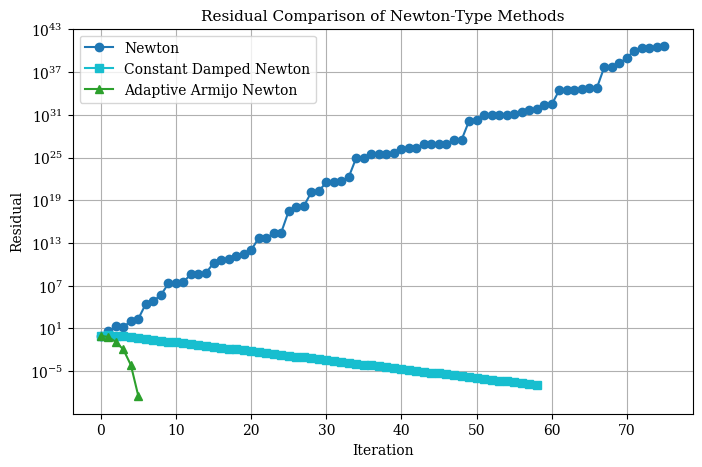

In [7]:
plt.figure(figsize=(8, 5))

# palette without yellow/orange: custom hex list (blues/teals/purples/greens)
palette = [
    '#1f77b4',  # blue
    '#17becf',  # cyan
    '#2ca02c',  # green
    '#9467bd',  # purple
    '#4daf4a',  # darker green
    '#7b4173',  # magenta-ish
    '#3182bd',  # steel blue
    '#66c2a5',  # teal
]
method_colors = dict(zip(methods.keys(), palette))
markers = ['o', 's', '^', 'D', 'x', 'v', '>', '<']

for (name, result), m in zip(methods.items(), markers):
    residuals = residuals_for_plot(result)

    if residuals:
        plt.semilogy(
            range(len(residuals)),
            residuals,
            marker=m,
            color=method_colors[name],
            label=name,
            linewidth=1.5
        )

plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.title("Residual Comparison of Newton-Type Methods")

plt.legend()
plt.grid(True)

plt.savefig(
    "../latex/figures/armijo_residual_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [8]:
residual_consistency_report(methods)

,Method,Iterations,History Last Residual,Final Residual,Plot Last Residual,Matches,Converged
0,Newton,75,3.804058e+40,4.448710e+40,4.448710e+40,True,False
1,Constant Damped Newton,58,1.533480e-07,1.150110e-07,1.150110e-07,True,True
2,Adaptive Armijo Newton,5,7.312605e-05,3.059162e-09,3.059162e-09,True,True


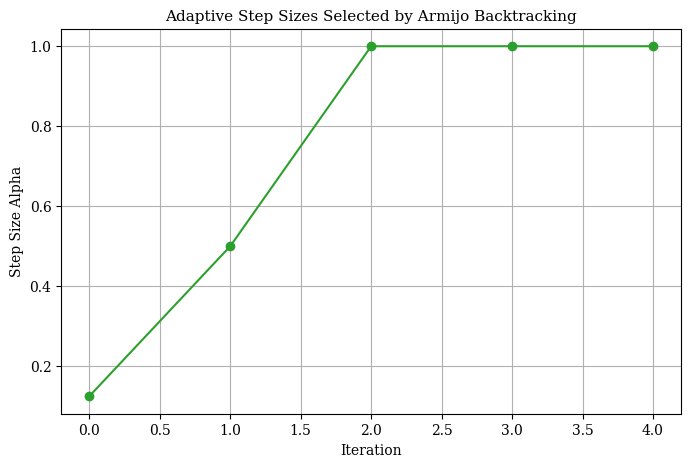

In [9]:
adaptive_history = methods["Adaptive Armijo Newton"]["history"]

alphas = [step["alpha"] for step in adaptive_history]

plt.figure(figsize=(8, 5))

# same custom palette as residual plot
palette = [
    '#1f77b4', '#17becf', '#2ca02c', '#9467bd',
    '#4daf4a', '#7b4173', '#3182bd', '#66c2a5',
]
method_colors = dict(zip(methods.keys(), palette))

plt.plot(
    range(len(alphas)),
    alphas,
    marker="o",
    color=method_colors.get("Adaptive Armijo Newton", '#1f77b4')
)

plt.xlabel("Iteration")
plt.ylabel("Step Size Alpha")
plt.title("Adaptive Step Sizes Selected by Armijo Backtracking")

plt.grid(True)

plt.savefig(
    "../latex/figures/armijo_alpha_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
